# 7. Missing Data & Imputation Analysis – Zein 

#### 📌 Project Problem Statement – Missing Data & Imputation
The goal of this analysis is to examine nearly a century of U.S. bank failure data to identify structural patterns such as crisis-driven spikes, geographic concentration, institutional characteristics, and cost variability, and to understand how different economic eras, regulatory environments, and bank types influenced the scale and financial impact of failures. (FDIC: BankFind Suite - Failures and Assistance)

#### 📊 Missing Data & Imputation Analysis
This section focuses on understanding how missing COST values affect the dataset and final insights.

It investigates whether missing data is random or systematic across time periods.
#### Key Questions
What happens if missing COST values are simply dropped from the dataset?

What happens if missing values are filled using imputation methods (Mean vs Median)?

How does each method change the overall data distribution and conclusions?

#### 📈 Visualizations Used

Missingness by Decade (Bar Chart) → shows where data is missing over time

Before vs After Histogram → compares original data with Mean and Median imputation

Decade-based comparison plots → shows impact of imputation across time periods

#### 🔍 Key Insights to Highlight

Missing COST values are not random and vary by decade

Dropping missing values causes bias toward more recent decades

Mean imputation distorts the distribution due to extreme outliers

Median imputation provides a more stable and realistic representation of COST values

In [ ]:
#Import Libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import dash
from dash import dcc, html
from dash.dependencies import Input, Output, State
import plotly.express as px
import base64
import io

In [2]:
#Import the dataset 
df = pd.read_csv("failures_data.csv")

In [3]:
# Check the first rows of dataset 
df.head()

,BANKNO,BIDCITY,BIDNAME,BIDSTATE,BRDATE,BSTATUS,CERT,CHCLASS,CHCLASS1,CITY,...,PTRDATE,QBFASSET,QBFDEP,RESDATE,RESTYPE,RESTYPE1,SAVR,TERMI,UNINSDEP,URL
0,NaN,0,0,0,NaN,NaN,NaN,NM,NM,EAST PEORIA,...,0,374.0,238.0,NaN,FAILURE,PO,FDIC,NaN,NaN,NaN
1,NaN,0,0,0,NaN,NaN,NaN,NM,NM,GRANTWOOD,...,0,2305.0,590.0,NaN,FAILURE,PO,FDIC,NaN,NaN,NaN
2,NaN,0,0,0,NaN,NaN,NaN,NM,NM,CUMMINGS,...,0,NaN,30.0,NaN,FAILURE,P&A,FDIC,NaN,NaN,NaN
3,NaN,LINCOLN,UNION BANK&TRUST CO,NE,NaN,I,13797.0,NM,NM,TAYLOR,...,0,14542.0,13360.0,5/31/1985,FAILURE,PA,FDIC,T,NaN,na
4,NaN,0,0,0,NaN,I,18388.0,NM,NM,FAIRFIELD,...,0,6795.0,6034.0,5/31/1985,FAILURE,PO,FDIC,T,NaN,na


In [4]:
# Check dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4114 entries, 0 to 4113
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   BANKNO              747 non-null    float64
 1   BIDCITY             4114 non-null   object 
 2   BIDNAME             4114 non-null   object 
 3   BIDSTATE            3873 non-null   object 
 4   BRDATE              930 non-null    object 
 5   BSTATUS             2903 non-null   object 
 6   CERT                3626 non-null   float64
 7   CHCLASS             4114 non-null   object 
 8   CHCLASS1            4114 non-null   object 
 9   CITY                4114 non-null   object 
 10  CITYST              4114 non-null   object 
 11  CLOSCD              2656 non-null   object 
 12  COMMENTS            75 non-null     object 
 13  COST                3476 non-null   float64
 14  COSTMOSTRECENTASOF  3551 non-null   object 
 15  FAILDATE            4114 non-null   object 
 16  FAILYR

In [5]:
# get the columns names 
df.columns

Index(['BANKNO', 'BIDCITY', 'BIDNAME', 'BIDSTATE', 'BRDATE', 'BSTATUS', 'CERT',
       'CHCLASS', 'CHCLASS1', 'CITY', 'CITYST', 'CLOSCD', 'COMMENTS', 'COST',
       'COSTMOSTRECENTASOF', 'FAILDATE', 'FAILYR', 'FIN', 'FSL_PROG', 'FUND',
       'ID', 'NAME', 'PSTALP', 'PTRDATE', 'QBFASSET', 'QBFDEP', 'RESDATE',
       'RESTYPE', 'RESTYPE1', 'SAVR', 'TERMI', 'UNINSDEP', 'URL'],
      dtype='object')

In [6]:
# Check the dataset dimension
df.shape 

(4114, 33)

In [7]:
# Statistical summary of dataset 
df.describe()

,BANKNO,CERT,COST,FAILYR,FIN,FUND,ID,QBFASSET,QBFDEP,UNINSDEP
count,747.000000,3626.000000,3.476000e+03,4114.000000,4114.000000,4114.000000,4114.000000,3.960000e+03,4.112000e+03,167.000000
mean,8339.172691,24519.545229,8.463684e+04,1985.556636,4184.461595,2.010452,2057.500000,1.366029e+06,7.526654e+05,4801.880240
std,349.638493,11666.221909,5.264909e+05,18.386663,3336.837640,1.384200,1187.753833,3.127343e+07,1.620112e+07,11897.867376
min,7701.000000,40.000000,-1.138100e+04,1934.000000,0.000000,1.000000,1.000000,1.400000e+01,0.000000e+00,1.000000
25%,7964.500000,18268.500000,3.151500e+03,1985.000000,1755.250000,1.000000,1029.250000,1.801125e+04,1.464375e+04,131.500000
50%,8396.000000,26354.500000,1.131500e+04,1988.000000,2969.500000,1.000000,2057.500000,5.563150e+04,4.958600e+04,633.000000
75%,8595.500000,30988.500000,4.290175e+04,1991.000000,7033.750000,3.000000,3085.750000,1.976018e+05,1.751820e+05,3677.000000
max,8925.000000,91189.000000,1.895962e+07,2026.000000,12894.000000,5.000000,4114.000000,1.471631e+09,9.546776e+08,95318.000000


In [8]:
# Get statistical summary of the COST column  
df["COST"].describe()

count    3.476000e+03
mean     8.463684e+04
std      5.264909e+05
min     -1.138100e+04
25%      3.151500e+03
50%      1.131500e+04
75%      4.290175e+04
max      1.895962e+07
Name: COST, dtype: float64

In [9]:
# Check total of missing values for COST
cost_missing_values =  df["COST"].isnull().sum()

print("Total Missing values in COST", df["COST"].isnull().sum())

Total Missing values in COST 638


In [10]:
# Percentage of missing COST values
missing_percent = (df["COST"].isnull().sum() / len(df)) * 100

print(f"Missing COST values: {missing_percent:.2f}%")

Missing COST values: 15.51%


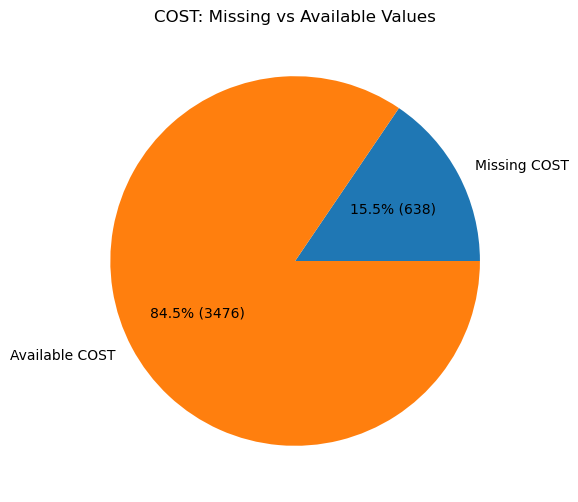

In [11]:
# Missing COST vs Available COST

# Calculate values
cost_missing = df["COST"].isnull().sum()
total = len(df)
cost_not_missing = total - cost_missing

# Data for pie chart
labels = ["Missing COST", "Available COST"]
sizes = [cost_missing, cost_not_missing]

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct=lambda p: f"{p:.1f}% ({int(p*sum(sizes)/100)})"
)
plt.title("COST: Missing vs Available Values")
plt.show()

#### Inference:
The pie chart indicates that 15.5% (638 records) of the COST dataset is missing, representing a notable portion of data that requires imputation. However, with 84.5% (3,476 records) of the data available, there remains a highly robust baseline of historical values to accurately guide the median imputation strategy.

### Create Decade Column

In [12]:
# Create decade column
df["DECADE"] = (df["FAILYR"] // 10) * 10

# Check result
print(df[["FAILYR", "DECADE"]].head(10))

   FAILYR  DECADE
0    1934    1930
1    1935    1930
2    1936    1930
3    1985    1980
4    1985    1980
5    1985    1980
6    1985    1980
7    1985    1980
8    1985    1980
9    1985    1980


### Missingness by Decade

In [13]:
# Count missing COST values by decade
# missing_by_decade = (
#     df.groupby("DECADE")["COST"]
#     .apply(lambda x: x.isnull().mean() * 100)
#     .reset_index(name="Missing_Percent")
# )

missing_by_decade = df.groupby("DECADE")["COST"].agg(
    Total_Missing=lambda x: x.isnull().sum(),
    Missing_Percent=lambda x: x.isnull().mean() * 100
).reset_index()


print(missing_by_decade)

   DECADE  Total_Missing  Missing_Percent
0    1930            312       100.000000
1    1940             99       100.000000
2    1950             28       100.000000
3    1960             44       100.000000
4    1970             79       100.000000
5    1980             61         2.996071
6    1990              1         0.108108
7    2000             13         6.190476
8    2010              0         0.000000
9    2020              1         7.142857


### Visualization — Missingness by Decade

C:\Users\Zein\AppData\Local\Temp\ipykernel_30160\288220027.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


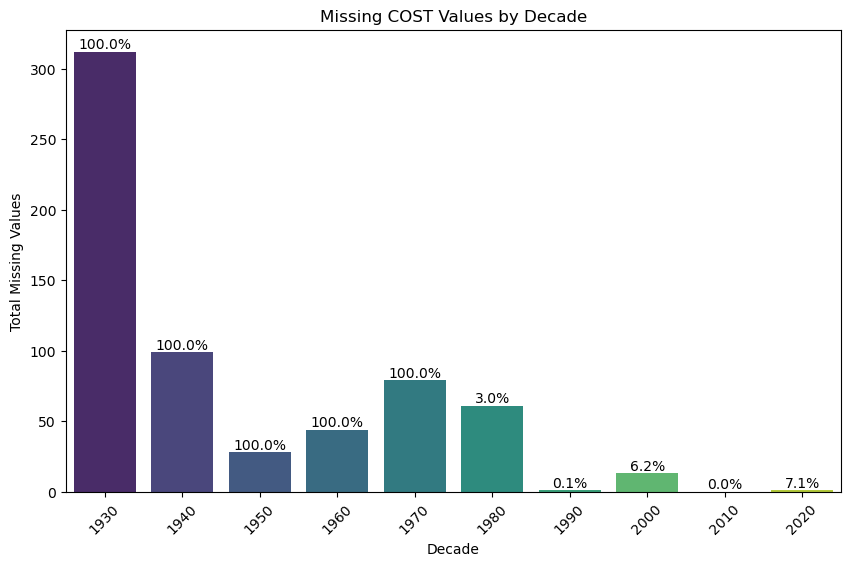

In [14]:
plt.figure(figsize=(10,6))

# Different colors per bar
colors = sns.color_palette("viridis", len(missing_by_decade))

ax = sns.barplot(
    data=missing_by_decade,
    x="DECADE",
    y="Total_Missing",
    palette=colors
)

plt.title("Missing COST Values by Decade")
plt.xlabel("Decade")
plt.ylabel("Total Missing Values")

# Add % labels on top of bars
for i, row in missing_by_decade.iterrows():
    ax.text(
        i,
        row["Total_Missing"],
        f'{row["Missing_Percent"]:.1f}%',
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=45)
plt.show()

#### Inference & Insights:

Historical Data Blackout (1930s–1970s): There is a complete 100.0% missing rate for COST values prior to 1980, meaning any historical analysis for these decades relies entirely on your imputed values.

Modern Era Completeness (1990s–Present): Data collection dramatically improves in the modern era, with missing rates dropping to near-zero (e.g., 0.1% in the 1990s and 0.0% in the 2010s), indicating highly reliable recent records.

### Drop Missing COST Values

In [15]:
# Dataset after dropping missing COST values
df_drop = df.dropna(subset=["COST"])

print("Original Shape:", df.shape)
print("After Dropping Missing COST:", df_drop.shape)

Original Shape: (4114, 34)
After Dropping Missing COST: (3476, 34)


In [16]:
# Original decade counts
original_counts = df["DECADE"].value_counts().sort_index()

# After dropping missing COST
drop_counts = df_drop["DECADE"].value_counts().sort_index()

comparison = pd.DataFrame({
    "Original": original_counts,
    "After_Drop": drop_counts
})

# Fill NaN with 0 and convert to int
comparison = comparison.fillna(0).astype(int)

print(comparison)

        Original  After_Drop
DECADE                      
1930         312           0
1940          99           0
1950          28           0
1960          44           0
1970          79           0
1980        2036        1975
1990         925         924
2000         210         197
2010         367         367
2020          14          13


### Mean and Median Imputation

In [17]:
# Create copies
df_mean = df.copy()
df_median = df.copy()

# Mean imputation
mean_value = df["COST"].mean()
df_mean["COST"] = df_mean["COST"].fillna(mean_value)

# Median imputation
median_value = df["COST"].median()
df_median["COST"] = df_median["COST"].fillna(median_value)

print("Mean:", mean_value)
print("Median:", median_value)

Mean: 84636.83573072497
Median: 11315.0


### Histogram Comparison

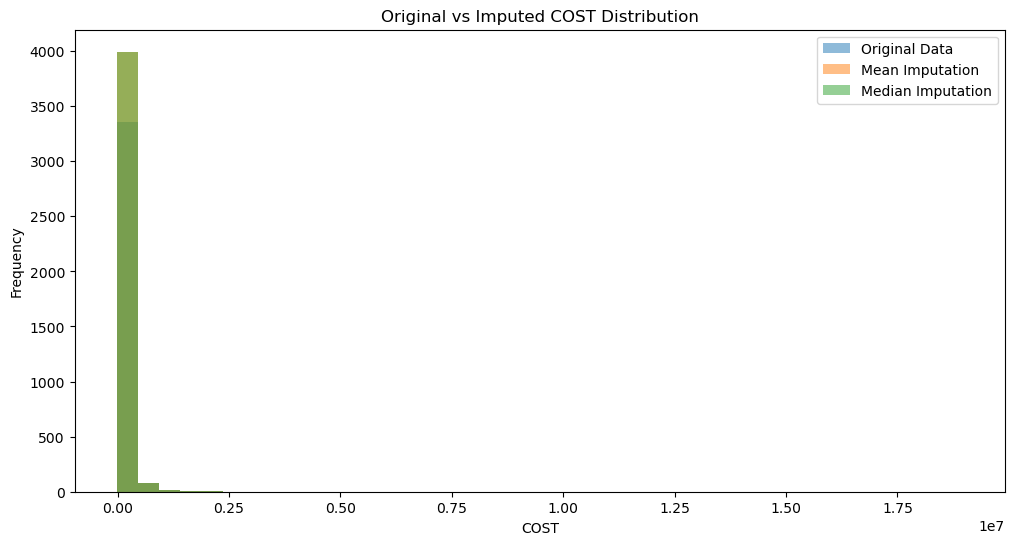

In [18]:
plt.figure(figsize=(12,6))

# Original data
plt.hist(
    df["COST"].dropna(),
    bins=40,
    alpha=0.5,
    label="Original Data"
)

# Mean imputation
plt.hist(
    df_mean["COST"],
    bins=40,
    alpha=0.5,
    label="Mean Imputation"
)

# Median imputation
plt.hist(
    df_median["COST"],
    bins=40,
    alpha=0.5,
    label="Median Imputation"
)

# Titles and labels
plt.title("Original vs Imputed COST Distribution")
plt.xlabel("COST")
plt.ylabel("Frequency")

# Legend
plt.legend()

plt.show()

#### Inference & Insights:

Extreme Right-Skewed Distribution: The histogram visually confirms that the COST data is heavily right-skewed, with the vast majority of records concentrated near zero and a long, sparse tail extending all the way toward $1.89 \times 10^7$ (19 million).

Imputation Spike Visualization: Because the data is so tightly clustered in the first bin, both imputation methods simply stack the 638 missing values into the same extreme lower range, visually increasing the main frequency peak from roughly 3,300 to nearly 4,000 records.

In [19]:
# Create comparison dataframe
comparison_stats = pd.DataFrame({
    "Dataset": ["Original", "Mean Imputed", "Median Imputed"],
    "Mean_COST": [
        df["COST"].mean(),
        df_mean["COST"].mean(),
        df_median["COST"].mean()
    ],
    "Median_COST": [
        df["COST"].median(),
        df_mean["COST"].median(),
        df_median["COST"].median()
    ]
})

print(comparison_stats)

          Dataset     Mean_COST  Median_COST
0        Original  84636.835731      11315.0
1    Mean Imputed  84636.835731      17801.0
2  Median Imputed  73266.069762      11315.0


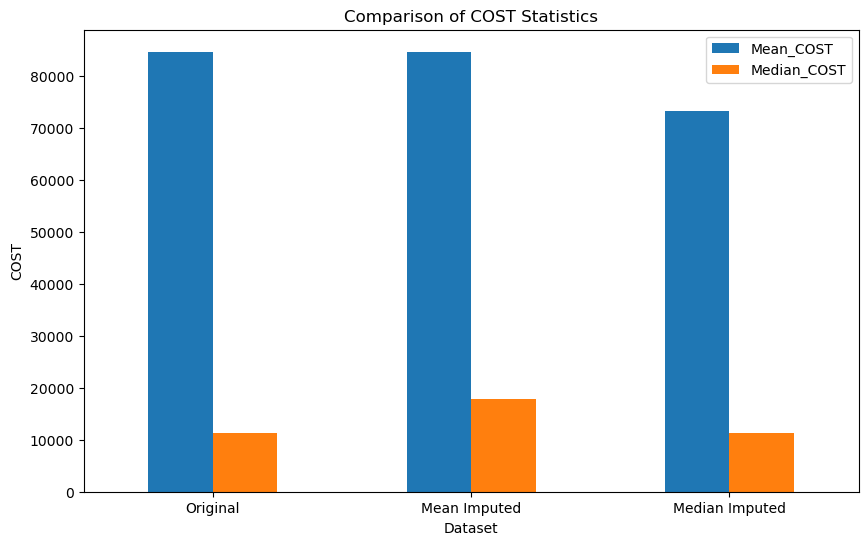

In [20]:
comparison_stats.plot(
    x="Dataset",
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of COST Statistics")
plt.ylabel("COST")

plt.xticks(rotation=0)

plt.show()

#### Inference & Insights
**Mean Imputation Distorts the Center:**
In the middle cluster (Mean Imputed), filling missing values using the mean increases the median value to 17,801, showing that mean imputation changes the typical center of the data due to extreme outliers.

**Median Imputation Preserves the Original Distribution:**
In the third cluster (Median Imputed), the median remains close to the original value (11,315), indicating that median imputation better preserves the true characteristics of the skewed COST distribution.

In [21]:
# Missingness Pattern
print(missing_by_decade)

   DECADE  Total_Missing  Missing_Percent
0    1930            312       100.000000
1    1940             99       100.000000
2    1950             28       100.000000
3    1960             44       100.000000
4    1970             79       100.000000
5    1980             61         2.996071
6    1990              1         0.108108
7    2000             13         6.190476
8    2010              0         0.000000
9    2020              1         7.142857


In [22]:
# Bias After Dropping Rows
print(comparison)

        Original  After_Drop
DECADE                      
1930         312           0
1940          99           0
1950          28           0
1960          44           0
1970          79           0
1980        2036        1975
1990         925         924
2000         210         197
2010         367         367
2020          14          13


In [65]:
# Imputation Effect
print("Original Data:", df["COST"].describe())
print("----------------------")
print("Mean Imputation:", df_mean["COST"].describe())
print("----------------------")
print("Median Imputation:", df_median["COST"].describe())

Original Data: count    3.476000e+03
mean     8.463684e+04
std      5.264909e+05
min     -1.138100e+04
25%      3.151500e+03
50%      1.131500e+04
75%      4.290175e+04
max      1.895962e+07
Name: COST, dtype: float64
----------------------
Mean Imputation: count    4.114000e+03
mean     8.463684e+04
std      4.839371e+05
min     -1.138100e+04
25%      4.050250e+03
50%      1.780100e+04
75%      8.463684e+04
max      1.895962e+07
Name: COST, dtype: float64
----------------------
Median Imputation: count    4.114000e+03
mean     7.326607e+04
std      4.846646e+05
min     -1.138100e+04
25%      4.050250e+03
50%      1.131500e+04
75%      3.242550e+04
max      1.895962e+07
Name: COST, dtype: float64


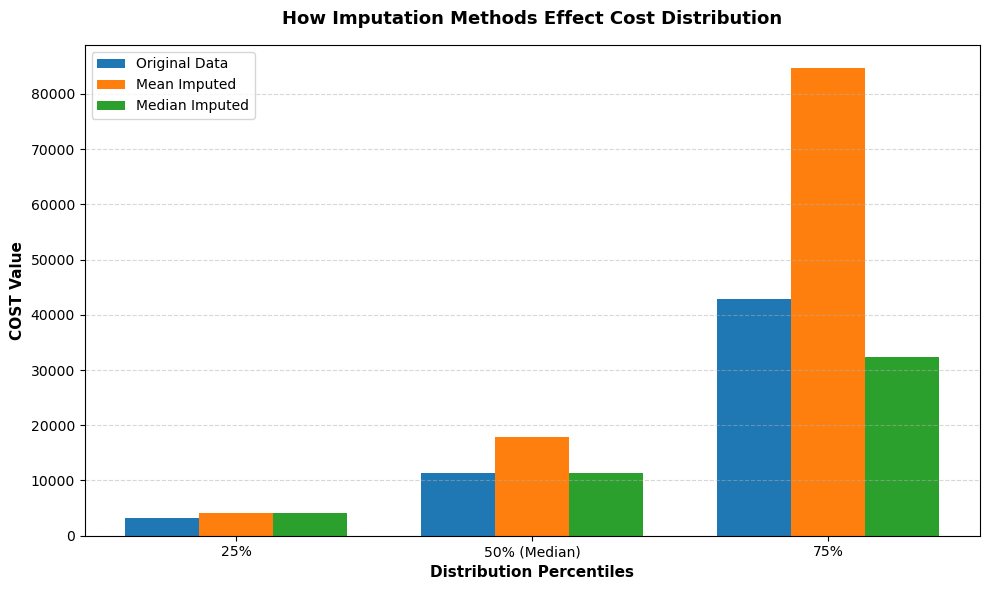

In [67]:
# Dynamically pull percentiles and data values directly from your DataFrames
percentiles = ['25%', '50% (Median)', '75%']

original_data = [
    df["COST"].quantile(0.25), 
    df["COST"].quantile(0.50), 
    df["COST"].quantile(0.75)
]

mean_imputed = [
    df_mean["COST"].quantile(0.25), 
    df_mean["COST"].quantile(0.50), 
    df_mean["COST"].quantile(0.75)
]

median_imputed = [
    df_median["COST"].quantile(0.25), 
    df_median["COST"].quantile(0.50), 
    df_median["COST"].quantile(0.75)
]

# X positions for the groups
x = np.arange(len(percentiles))
bar_width = 0.25

# Create the figure
plt.figure(figsize=(10, 6))

# Plotting each dataset's bars with explicit positions
plt.bar(x - bar_width, original_data, width=bar_width, label='Original Data', color='#1f77b4')
plt.bar(x, mean_imputed, width=bar_width, label='Mean Imputed', color='#ff7f0e')
plt.bar(x + bar_width, median_imputed, width=bar_width, label='Median Imputed', color='#2ca02c')

# Labels, Title, and Formatting
plt.xlabel('Distribution Percentiles', fontsize=11, fontweight='bold')
plt.ylabel('COST Value', fontsize=11, fontweight='bold')
plt.title('How Imputation Methods Effect Cost Distribution', fontsize=13, fontweight='bold', pad=15)

# Set the x-ticks to align perfectly with the middle bar of each group
plt.xticks(x, percentiles)

# Add a subtle grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add the legend
plt.legend()

# Ensure layout doesn't clip titles/labels
plt.tight_layout()

# Display the chart
plt.show()

#### Inference:

Median Imputation is the best method for the COST variable because the data is highly right-skewed with a very large outlier (max ≈ 18.9M). This inflates the mean to 84,636.84, making it unrealistic.

With Mean Imputation, the median increases from 11,315 → 17,801 and the 75th percentile becomes 84,636.84, which distorts the distribution.

In contrast, Median Imputation keeps the center stable at 11,315 and preserves the natural spread of the data without being affected by extreme values.

Therefore, Median Imputation gives more realistic and reliable results for COST.

In [24]:
# Create decade column
df["DECADE"] = (df["FAILYR"] // 10) * 10

# Count original non-missing COST values
original_counts = (
    df.groupby("DECADE")["COST"]
    .apply(lambda x: x.notnull().sum())
)

# Count missing values (these are the imputed values)
missing_counts = (
    df.groupby("DECADE")["COST"]
    .apply(lambda x: x.isnull().sum())
)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    "Original_Data": original_counts,
    "Mean_Imputed": missing_counts,
    "Median_Imputed": missing_counts
}).reset_index()

print(comparison_df)

   DECADE  Original_Data  Mean_Imputed  Median_Imputed
0    1930              0           312             312
1    1940              0            99              99
2    1950              0            28              28
3    1960              0            44              44
4    1970              0            79              79
5    1980           1975            61              61
6    1990            924             1               1
7    2000            197            13              13
8    2010            367             0               0
9    2020             13             1               1


### Decade Imputation Comparison

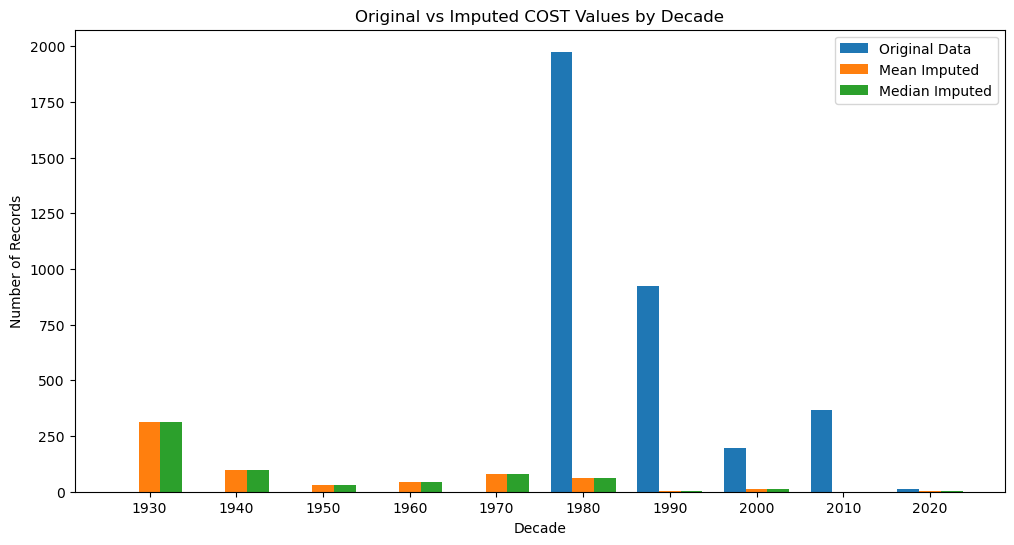

In [25]:
# Set figure size
plt.figure(figsize=(12,6))

# Width of bars
bar_width = 0.25

# X positions
x = np.arange(len(comparison_df["DECADE"]))

# Original data bars
plt.bar(
    x,
    comparison_df["Original_Data"],
    width=bar_width,
    label="Original Data"
)

# Mean imputed bars
plt.bar(
    x + bar_width,
    comparison_df["Mean_Imputed"],
    width=bar_width,
    label="Mean Imputed"
)

# Median imputed bars
plt.bar(
    x + (2 * bar_width),
    comparison_df["Median_Imputed"],
    width=bar_width,
    label="Median Imputed"
)

# Labels
plt.xlabel("Decade")
plt.ylabel("Number of Records")

# Title
plt.title("Original vs Imputed COST Values by Decade")

# X ticks
plt.xticks(
    x + bar_width,
    comparison_df["DECADE"]
)

# Legend
plt.legend()

plt.show()

#### Inference:

This plot effectively evaluates the impact of missing data treatment by contrasting the original dataset against mean and median imputation techniques across different eras. By grouping the distribution by DECADE, the graph allows for immediate identification that the peroid between 1930s to 1980s of historical periods that suffered from severe data loss and based on the height gaps between the original and imputed bars. Furthermore, comparing the "Mean Imputed" and "Median Imputed" bars side-by-side reveals whether underlying outliers are skewing the data, providing critical visual evidence to determine which imputation strategy maintains the most realistic volume of records for each decade.


=======================================================================

### Automated Missing Value Imputation Dashboard
#### For Handling Numerical Missing Data in Real-Time

#### 📌 Idea Overview

 Real-world datasets often contain missing values that can reduce accuracy and slow down analysis.
 
 This dashboard provides an automated and interactive solution to detect, analyze, and fix missing data quickly—without manual coding every time.

### ⚙️ How It Works (Simple Pipeline)

 1. 📥 Data Upload

    Upload CSV or Excel file
    Or use default dataset automatically

 2. 🔍 Missing Data Detection

    Finds missing values instantly

    Shows total records, missing count, and data types

 3. 🧠 Automatic Imputation

    Mean Imputation (average value)

    Median Imputation (middle value, better for outliers)

 4. 📊 Optional Time Analysis

    Group data by Year / Decade / Century

    Helps observe trends after cleaning

 5. 📈 Visual Insights

    Missing vs Non-missing (Pie chart)

    Missing values comparison (Bar chart)

    Mean vs Median comparison

    Before vs After distribution (Histogram)

    Box plot for outliers

 6. 🧩 Interactive Controls

    Dynamic dropdowns based on dataset

    Real-time updates without page refresh

#### 🎯 Outcome / Benefits

 Faster data cleaning process

 Easy understanding of missing data patterns

 Clear comparison of imputation methods

 Reusable tool for real-world datasets

 No need for manual coding each time

In [29]:
import sys
!{sys.executable} -m pip install dash

Defaulting to user installation because normal site-packages is not writeable
  Using cached dash-4.1.0-py3-none-any.whl.metadata (11 kB)
  Using cached retrying-1.4.2-py3-none-any.whl.metadata (5.5 kB)
Using cached dash-4.1.0-py3-none-any.whl (7.2 MB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.9 MB 5.1 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.9 MB 5.1 MB/s eta 0:00:02
   ------------ --------------------------- 3.1/9.9 MB 5.3 MB/s eta 0:00:02
   ---------------- ----------------------- 4.2/9.9 MB 5.4 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.9 MB 5.3 MB/s eta 0:00:01
   ------------------------- -------------- 6.3/9.9 MB 5.4 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.9 MB 5.4 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.9 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 5.4 MB/s eta 0:


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Zein\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [69]:
# =========================================================
# DEFAULT DATASET
# =========================================================

default_df = pd.read_csv("failures_data.csv")

# =========================================================
# APP
# =========================================================

app = dash.Dash(__name__)

# =========================================================
# STYLES
# =========================================================

TITLE_STYLE = {
    'textAlign': 'center',
    'color': '#1E90FF',
    'fontWeight': 'bold',
    'textShadow': '2px 2px 5px #87CEFA',
    'marginBottom': '30px'
}

SUBTITLE_STYLE = {
    'color': '#1E90FF',
    'fontWeight': 'bold'
}

# =========================================================
# LAYOUT
# =========================================================

app.layout = html.Div([

    html.H1(
        "Automated Missing Value Imputation Dashboard",
        style=TITLE_STYLE
    ),

    # FIRST ROW
    html.Div([

        html.Div([

            html.Label("Upload Dataset", style=SUBTITLE_STYLE),

            dcc.Upload(
                id='upload-data',
                children=html.Div(["Drag & Drop or Click to Upload"]),
                style={
                    'backgroundColor': '#f0f8ff',
                    'border': '2px dashed #1E90FF',
                    'padding': '10px',
                    'textAlign': 'center'
                }
            )

        ], style={'width': '45%'}),

        html.Div([

            html.Label("File Type", style=SUBTITLE_STYLE),

            dcc.Dropdown(
                id='file-type',
                options=[
                    {'label': 'CSV', 'value': 'csv'},
                    {'label': 'Excel', 'value': 'excel'}
                ],
                value='csv'
            )

        ], style={'width': '45%'})

    ], style={'display': 'flex', 'justifyContent': 'space-between'}),

    html.Br(),

    # SECOND ROW
    html.Div([

        html.Div([

            html.Label("Numeric Column with Missing Values", style=SUBTITLE_STYLE),

            dcc.Dropdown(id='missing-column')

        ], style={'width': '30%'}),

        html.Div([

            html.Label("Column to Impute Missing Values By", style=SUBTITLE_STYLE),

            # ✅ FIXED HERE (no default selection)
            dcc.Dropdown(
                id='impute-column',
                placeholder="Select a column (required)"
            )

        ], style={'width': '30%'}),

        html.Div([

            html.Label("Time Grouping", style=SUBTITLE_STYLE),

            dcc.Dropdown(
                id='time-group',
                options=[
                    {'label': 'Year', 'value': 'year'},
                    {'label': 'Decade', 'value': 'decade'},
                    {'label': 'Century', 'value': 'century'}
                ],
                value='decade',
                disabled=True
            )

        ], style={'width': '30%'})

    ], style={'display': 'flex', 'justifyContent': 'space-between'}),

    html.Br(),

    # KPI SECTION
    html.Div([

        html.Div([html.H3("Total"), html.H2(id='kpi-total')]),
        html.Div([html.H3("Missing"), html.H2(id='kpi-missing')]),
        html.Div([html.H3("Mean"), html.H2(id='kpi-mean')]),
        html.Div([html.H3("Median"), html.H2(id='kpi-median')]),
        html.Div([html.H3("Column Type"), html.H2(id='kpi-type')])

    ], style={
        'display': 'flex',
        'justifyContent': 'space-between',
        'backgroundColor': '#D3D3D3',
        'padding': '15px',
        'borderRadius': '10px'
    }),

    html.Br(),

    dcc.Graph(id='pie-chart'),

    html.Div([
        dcc.Graph(id='missing-chart'),
        dcc.Graph(id='mean-median-chart')
    ], style={'display': 'flex'}),

    html.Div([
        # dcc.Graph(id='comparison-chart'),
        dcc.Graph(id='box-plot'),
        dcc.Graph(id='histogram-chart')
    ], style={'display': 'flex'}),



])

# =========================================================
# LOAD DATA FUNCTION
# =========================================================

def load_data(contents, filename):

    if contents is None:
        return default_df

    content_type, content_string = contents.split(',')
    decoded = base64.b64decode(content_string)

    try:
        if 'csv' in filename.lower():
            df = pd.read_csv(io.StringIO(decoded.decode('utf-8')))
        else:
            df = pd.read_excel(io.BytesIO(decoded))
        return df

    except Exception as e:
        print("UPLOAD ERROR:", e)
        return default_df

# =========================================================
# DROPDOWN CALLBACK
# =========================================================

@app.callback(
    [
        Output('missing-column', 'options'),
        Output('missing-column', 'value'),

        Output('impute-column', 'options'),
        Output('impute-column', 'value'),

        Output('time-group', 'disabled')
    ],
    [
        Input('upload-data', 'contents'),
        Input('impute-column', 'value') 
    ],
    State('upload-data', 'filename')
)
def update_dropdowns(contents, impute_col, filename):

    df = load_data(contents, filename)

    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    missing_cols = [
        c for c in numeric_cols
        if df[c].isnull().sum() > 0
    ]

    all_cols = df.columns.tolist()

    missing_value = missing_cols[0] if missing_cols else None

    # ✅ FIX: no auto selection
    # impute_value = None
    impute_value = impute_col

    time_disabled = True

    if impute_col is not None and impute_col in df.columns:
        col_dtype = df[impute_col].dtype

        if (
            np.issubdtype(col_dtype, np.number) or
            np.issubdtype(col_dtype, np.datetime64)
        ):
            time_disabled = False   # ✅ ENABLE dropdown
        else:
            time_disabled = True    # ❌ DISABLE dropdown

    return (
        [{'label': c, 'value': c} for c in missing_cols],
        missing_value,
        [{'label': c, 'value': c} for c in all_cols],
        impute_value,
        time_disabled
    )

# =========================================================
# MAIN DASHBOARD CALLBACK
# =========================================================

@app.callback(
    [
        Output('kpi-total', 'children'),
        Output('kpi-missing', 'children'),
        Output('kpi-mean', 'children'),
        Output('kpi-median', 'children'),
        Output('kpi-type', 'children'),

        Output('pie-chart', 'figure'),
        Output('missing-chart', 'figure'),
        Output('mean-median-chart', 'figure'),
        # Output('comparison-chart', 'figure'),
        Output('box-plot', 'figure'),
        Output('histogram-chart', 'figure')
    ],
    [
        Input('missing-column', 'value'),
        Input('impute-column', 'value'),
        Input('time-group', 'value')
    ],
    [
        State('upload-data', 'contents'),
        State('upload-data', 'filename')
    ]
)
def update_dashboard(
    missing_col,
    impute_col,
    time_group,
    contents,
    filename
):

    df = load_data(contents, filename)

    if missing_col is None or missing_col not in df.columns:
        return "", "", "", "", "", {}, {}, {}, {}, {}, {}

    total = len(df)
    missing = df[missing_col].isnull().sum()
    mean_val = round(df[missing_col].mean(), 2)
    median_val = round(df[missing_col].median(), 2)
    dtype = str(df[missing_col].dtype)

    col_type = (
        "Numeric" if ("float" in dtype or "int" in dtype)
        else "Date/Time" if "datetime" in dtype
        else "Categorical"
    )

    pie_df = pd.DataFrame({
        "Category": ["Missing", "Non-Missing"],
        "Count": [
            df[missing_col].isnull().sum(),
            df[missing_col].notnull().sum()
        ]
    })

    pie_chart = px.pie(
        pie_df,
        names="Category",
        values="Count",
        title="Missing vs Non-Missing Distribution",
        hole=0.4
    )

    missing_chart = px.bar(
        pie_df,
        x="Category",
        y="Count",
        color="Category",
        title="Missing vs Non-Missing"
    )

    mm_df = pd.DataFrame({
        "Stat": ["Mean", "Median"],
        "Value": [mean_val, median_val]
    })

    mean_median_chart = px.bar(
        mm_df,
        x="Stat",
        y="Value",
        title="Mean vs Median",
        color="Stat",
        text="Value"
    )

    # comparison_chart = {}

    box_plot = px.box(df, y=missing_col, title="Distribution")

    hist_df = pd.DataFrame({
        "Original": df[missing_col],
        "Mean Imputed": df[missing_col].fillna(df[missing_col].mean()),
        "Median Imputed": df[missing_col].fillna(df[missing_col].median())
    })

    histogram_chart = px.histogram(
        hist_df,
        barmode='overlay',
        title="Before vs After Imputation",
        opacity=0.6
    )

    return (
        total,
        missing,
        mean_val,
        median_val,
        col_type,
        pie_chart,
        missing_chart,
        mean_median_chart,
        # comparison_chart,
        box_plot,
        histogram_chart
    )

# =========================================================
# RUN APP
# =========================================================

if __name__ == "__main__":
    app.run(
        debug=True,
        host="127.0.0.1",
        port=8050,
        jupyter_mode="external"
    )
    

Dash app running on http://127.0.0.1:8050/
